# Parallel Streets — a Street Doppelgänger Atlas

We train an image encoder on street-level imagery from 20 cities, then ask
whether the learned embedding can find visually similar streets in distant
cities.

**The deliverable is the trained encoder.** No pretrained SAM / CLIP /
Florence-2 / YOLO / diffusion model does any of the work here. The ResNet50 is
trained from random initialisation on this data.

---

### Reported results come from the full local run

Every number and figure below comes from a full run on a local RTX 3080 Ti:
100,000 images, 20 epochs, ~75 minutes of training. `TRAIN_FROM_SCRATCH` is
`False` by default and loads the published checkpoint and cached embeddings, so
this notebook reproduces the *reported* results exactly. Setting it to `True`
genuinely retrains on a Colab T4 using a reduced config, but that shorter run
will not reproduce the headline numbers — it is there to prove the pipeline
runs end to end, not to re-derive the result.

### Honest summary of what we found

The encoder classifies city at **90.89% validation accuracy against 5% chance**,
and two runs from the same seed are bit-identical. But on the actual retrieval
task it **fails**: it is barely better than random at finding cross-city streets
that match on physical attributes, and clearly worse than frozen ImageNet
features. Stages 8 and 9 explain why, and that analysis stays in this notebook.

In [1]:
TRAIN_FROM_SCRATCH = False   # True genuinely retrains on a T4 with a reduced config

## Setup

In [2]:
# On Colab, clone the repo and install the pinned dependencies.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("acv_training"):
        subprocess.run(["git", "clone", "https://github.com/<user>/acv_training.git"], check=False)
    os.chdir("acv_training")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "timm==1.0.26", "umap-learn", "grad-cam"], check=False)
sys.path.insert(0, os.getcwd())

import torch, timm, torchvision
print("torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__)
print("CUDA:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

/home/dh/Project/person_projects/acv_training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0+cu128 | torchvision 0.25.0+cu128 | timm 1.0.26
CUDA: NVIDIA GeForce RTX 3080 Ti Laptop GPU


In [3]:
import numpy as np, pandas as pd
from pathlib import Path
from src.data import load_config
from src.dataset import build_split, make_loaders
from src.model import build_model, describe
from src.schema import load_schema, column_for, forbidden_columns

cfg = load_config()
if TRAIN_FROM_SCRATCH and IN_COLAB:
    cfg["train"].update(cfg["notebook"]["colab_reduced"])
    cfg["dataloader"]["batch_size"] = cfg["notebook"]["colab_reduced"]["batch_size"]
    cfg["dataloader"]["num_workers"] = 2
cfg["project"]["seed"]

1337

## Stage 0 — schema

Column names in this dataset are not guessable, so nothing is hard-coded. They
were read from `info.csv` and then verified against the live CSV headers on
HuggingFace. `schema.json` is the record.

In [4]:
schema = load_schema()
for role in ["city", "sequence_id", "greenery", "road_type"]:
    print(f"{role:14} -> {schema['roles'][role]['file']:38} {column_for(role)}")
print(f"{'building_density':14} -> DERIVED: "
      f"{schema['roles']['building_density']['expression']} "
      f"(no such column ships with the dataset)")
print("\nnever used (rule 2):", forbidden_columns())

city           -> data/simplemaps.csv                    city_ascii
sequence_id    -> data/metadata_common_attributes.csv    sequence_id
greenery       -> data/segmentation.csv                  green_view_index
road_type      -> data/osm.csv                           highway
building_density -> DERIVED: Building / Total (no such column ships with the dataset)

never used (rule 2): ['Safe', 'Lively', 'Beautiful', 'Wealthy', 'Boring', 'Depressing']


## Stages 1–2 — subset and imagery

20 cities across all six continents, chosen for distinct Köppen climate zones
and matched on SimpleMaps `city_id` (city name strings are not globally unique).
5,000 images per city, 100,000 total, pre-resized to 256 px.

**Panoramas are excluded.** Panorama share is severely confounded with city
(Lima 81.5%, Athens 68.2%, São Paulo 0.0%), so training across mixed
projections would let the encoder separate cities on projection geometry rather
than streetscape content. Only `perspective` and `fisheye` frames are used.

In [5]:
df = pd.read_parquet("data/interim/dataset.parquet")
classes = sorted(df.city_ascii.unique())
assert df.pano_status.fillna(False).astype(bool).sum() == 0, "panorama leaked in"
print(f"{len(df):,} images | {len(classes)} cities | "
      f"{df.sequence_id.nunique():,} sequences")
df.groupby(["continent", "city_ascii"]).size().rename("images").to_frame()

100,000 images | 20 cities | 17,509 sequences


images
continent     city_ascii           
Africa        Casablanca       5000
              Dar es Salaam    5000
              Kampala          5000
              Maseru           5000
Asia          Jakarta          5000
              Kuwait City      5000
              Singapore        5000
              Taipei           5000
              Tokyo            5000
Europe        Athens           5000
              Berlin           5000
              Lisbon           5000
              Moscow           5000
North America Ottawa           5000
              San Francisco    5000
              San Jose         5000
              Washington       5000
Oceania       Melbourne        5000
South America Lima             5000
              Sao Paulo        5000

## Stage 3 — dataloader, split by sequence ID

Mapillary and KartaView images come in sequences shot metres apart. A random
split would put near-duplicates on both sides and produce a meaningless
accuracy. The split is by `sequence_id`, stratified per city, and the
intersection is asserted empty.

In [6]:
train_df, val_df = build_split(df, cfg["dataloader"]["val_fraction"],
                               cfg["project"]["seed"])
overlap = set(train_df.sequence_id) & set(val_df.sequence_id)
print(f"train {len(train_df):,} | val {len(val_df):,}")
print(f"train/val sequence-ID intersection: {len(overlap)}")
assert not overlap, "RULE 1 VIOLATED"

train_loader, val_loader = make_loaders(train_df, val_df, classes, cfg)
xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)}   labels: {tuple(yb.shape)}")

train 79,707 | val 20,293
train/val sequence-ID intersection: 0


batch: (64, 3, 224, 224)   labels: (64,)


## Stage 4 — the encoder

timm ResNet50 with the classification head replaced, city classification as the
pretext task. `pretrained=False`: the weights start random. Switching
`encoder.backbone` in `config.yaml` to `vit_small_patch16_224` swaps in a small
ViT so the two can be compared later.

In [7]:
model = build_model(cfg, len(classes))
print(describe(model))

backbone=resnet50  embed_dim=2048
total params    : 23,549,012
trainable params: 23,549,012
head            : Linear(in_features=2048, out_features=20, bias=True)


## Stage 5 — training

Mixed precision, checkpoint every epoch, OneCycle schedule.

**Result: 90.89% validation accuracy against 5% chance (18.2×).** Two runs from
the same seed are bit-identical — same losses every epoch, same confusion
matrix, and every weight tensor equal to 0.0 absolute difference.

loaded published run: best val_acc = 0.9089 (chance 0.0500, 18.2x)


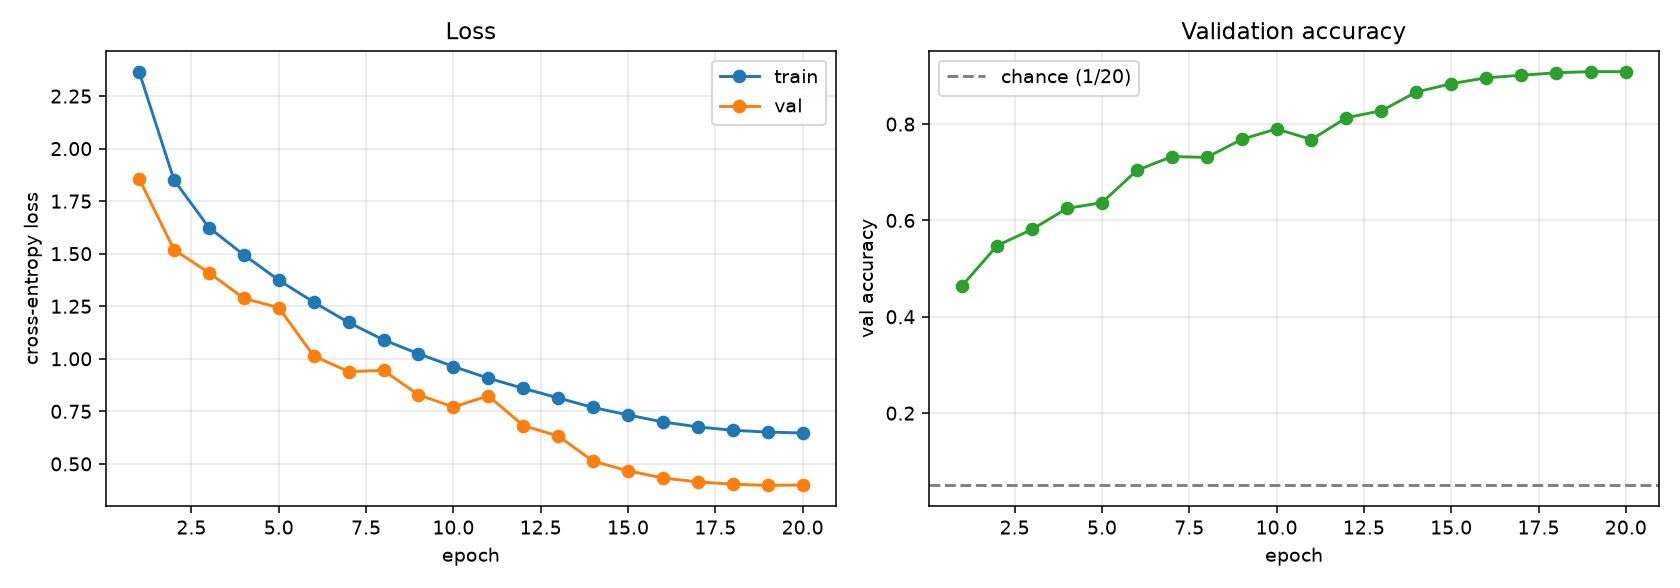

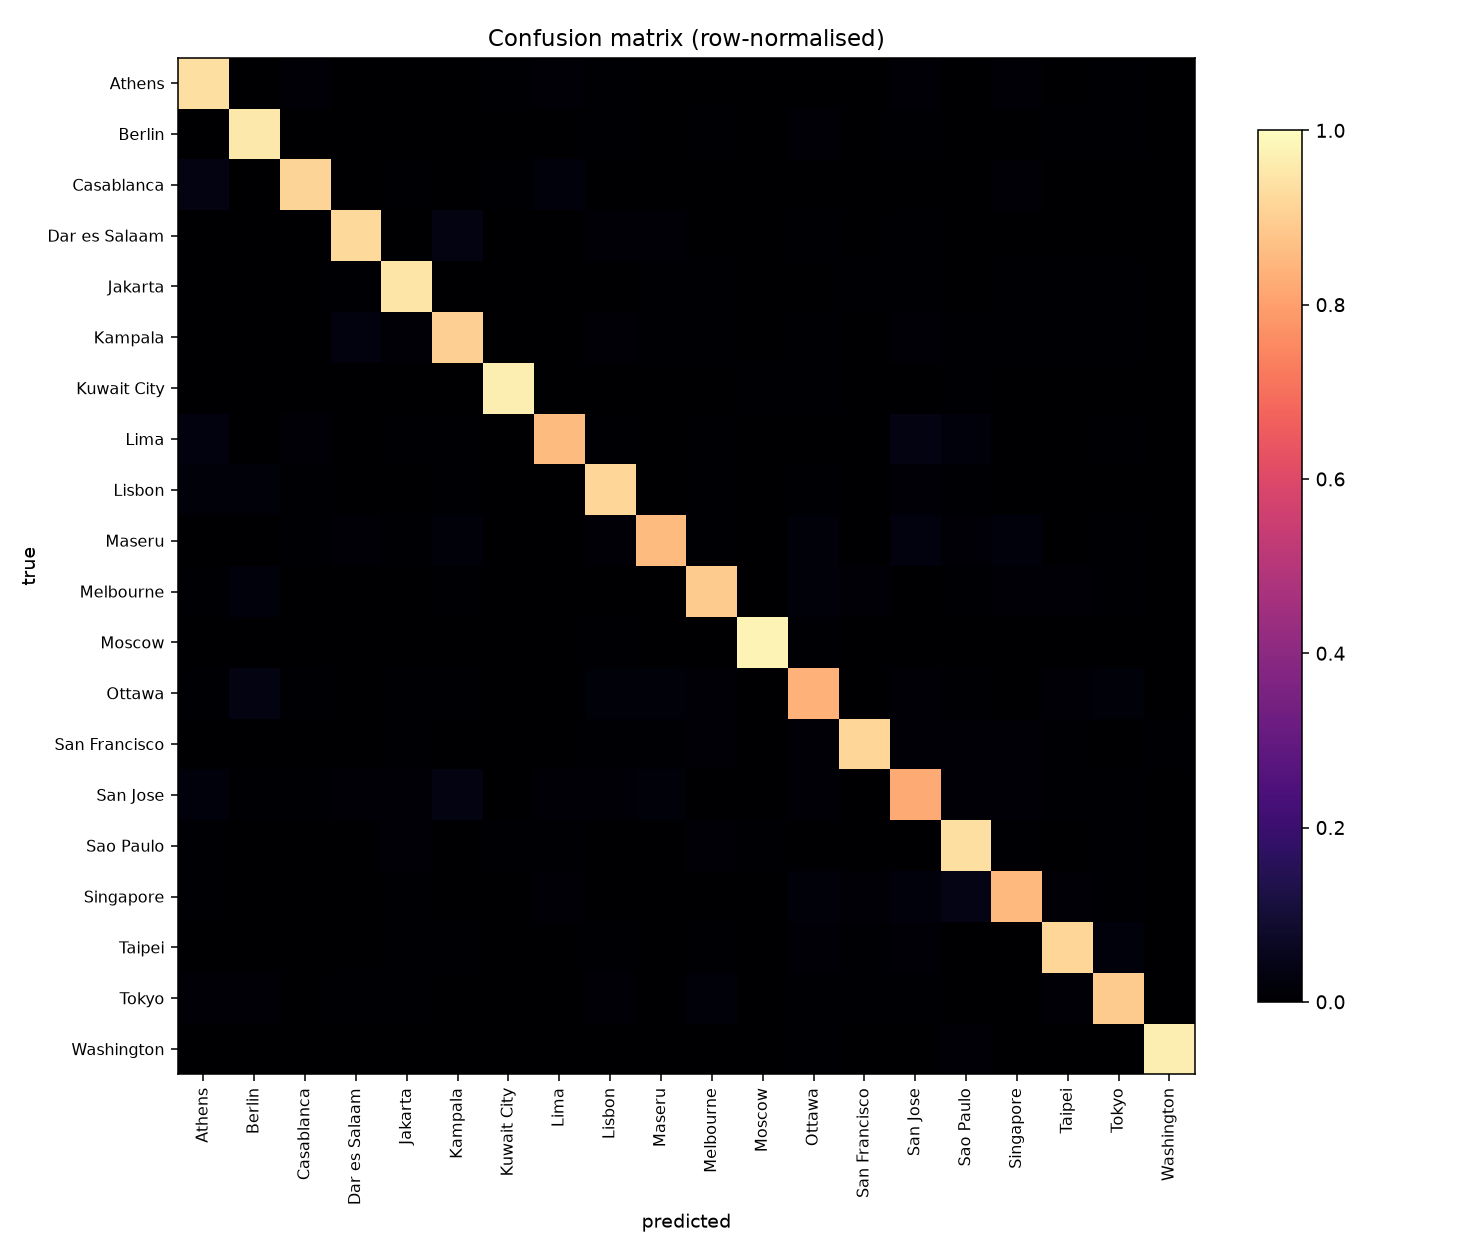

In [8]:
from src.train import set_seed, train
from src.viz import plot_history, plot_confusion
import json
from IPython.display import Image, display

if TRAIN_FROM_SCRATCH:
    set_seed(cfg["project"]["seed"])       # seed BEFORE the model is built
    model = build_model(cfg, len(classes))
    history, cm, best = train(model, train_loader, val_loader, cfg, classes,
                              tag="notebook")
    print(f"best val_acc = {best:.4f}")
else:
    hist = json.load(open("checkpoints/runA_history.json"))
    history, cm, best = hist["history"], hist["confusion_matrix"], hist["best_val_acc"]
    print(f"loaded published run: best val_acc = {best:.4f} "
          f"(chance {1/len(classes):.4f}, {best/(1/len(classes)):.1f}x)")

display(Image("outputs/runA_curves.png"))
display(Image("outputs/runA_confusion.png"))

In [9]:
# Reproducibility check, as run locally. Compare the metrics only - each
# epoch dict also carries "secs", the wall-clock time, which of course differs
# between two runs and says nothing about reproducibility.
import torch
a = json.load(open("checkpoints/runA_history.json"))
b = json.load(open("checkpoints/runB_history.json"))
METRICS = ["train_loss", "val_loss", "val_acc"]
identical = all(x[m] == y[m] for x, y in zip(a["history"], b["history"])
                for m in METRICS)
print("runA vs runB, same seed:")
print(f"  all {len(a['history'])} epochs identical on {METRICS}: {identical}")
print("  confusion matrices identical:", a["confusion_matrix"] == b["confusion_matrix"])
print(f"  best val_acc: {a['best_val_acc']:.6f} vs {b['best_val_acc']:.6f}")

wa = torch.load("checkpoints/runA_best.pt", map_location="cpu", weights_only=False)["model"]
wb = torch.load("checkpoints/runB_best.pt", map_location="cpu", weights_only=False)["model"]
print("  every weight tensor identical:", all(torch.equal(wa[k], wb[k]) for k in wa))

runA vs runB, same seed:
  all 20 epochs identical on ['train_loss', 'val_loss', 'val_acc']: True
  confusion matrices identical: True
  best val_acc: 0.908934 vs 0.908934
  every weight tensor identical: True


## Stage 6 — embeddings

The head is stripped and the 2048-d backbone output cached for all 100,000
images. The same is done with frozen ImageNet weights, for the comparison in
Stage 7.

In [10]:
from src.embed import load as load_emb
uuid_tr, E_trained  = load_emb(Path("data/interim/emb_trained.npz"))
uuid_in, E_imagenet = load_emb(Path("data/interim/emb_imagenet.npz"))
print("trained ", E_trained.shape)
print("imagenet", E_imagenet.shape)

trained  (100000, 2048)
imagenet (100000, 2048)


## Stage 7 — three retrieval systems, one metric

For each query we take the top-k neighbours **in other cities** and measure the
mean absolute difference in physical attributes, against randomly paired
streets as the control. Lower is better. A good embedding should retrieve
streets matching on attributes it was never shown.

Three systems answer the same 20 queries: our trained embedding, a normalised
tabular feature vector, and frozen ImageNet features.

In [11]:
results = pd.read_csv("outputs/stage7_results.csv", index_col=0)
results

,green_view_index,building_view_index,type_highway_mismatch
system,,,
trained (ours),0.14562,0.22657,0.31915
tabular (baseline),0.02395,0.03618,0.00000
frozen imagenet,0.09135,0.13356,0.28283
random control,0.15193,0.24319,0.33500


### Reading this table honestly

**Our trained embedding barely beats the random control.** 0.1456 vs 0.1519 on
greenery, 0.2266 vs 0.2432 on building density, 0.3191 vs 0.3350 on road-type
mismatch. The margin is real but small.

**Frozen ImageNet features are clearly better than ours** — 0.0914 on greenery
against our 0.1456. Features that were never trained on this data retrieve
attribute-matched streets better than the encoder we trained on it.

**The tabular baseline "wins" for a trivial reason and should not be read as a
result.** Its feature vector literally contains `green_view_index` and
`building_view_index`, and one-hot encodes `type_highway` — which is why its
road-type mismatch is exactly 0.0000. It is retrieving on the very columns
being scored. It is a sanity check on the metric, not a competitor.

So: on the task this project set out to do, the trained encoder failed. The
next two stages establish why.

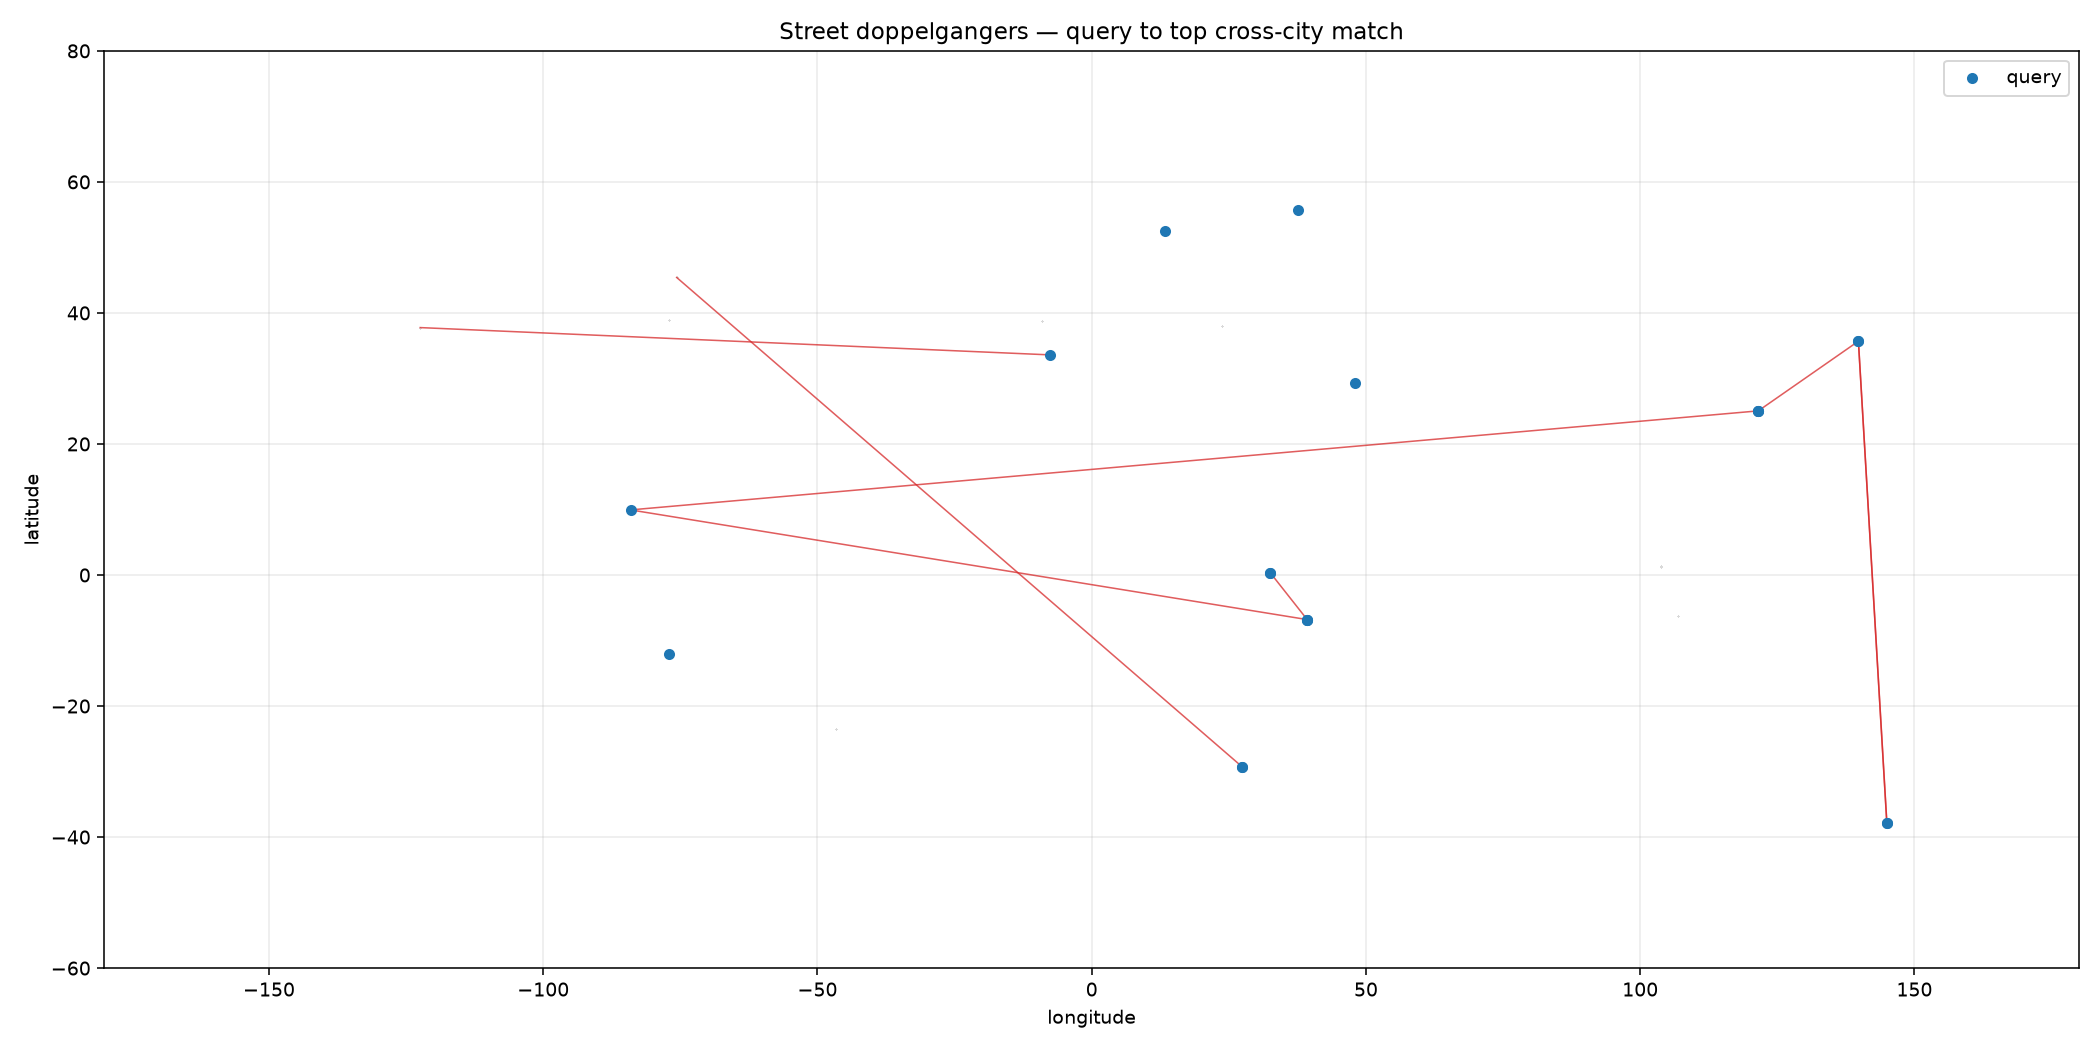

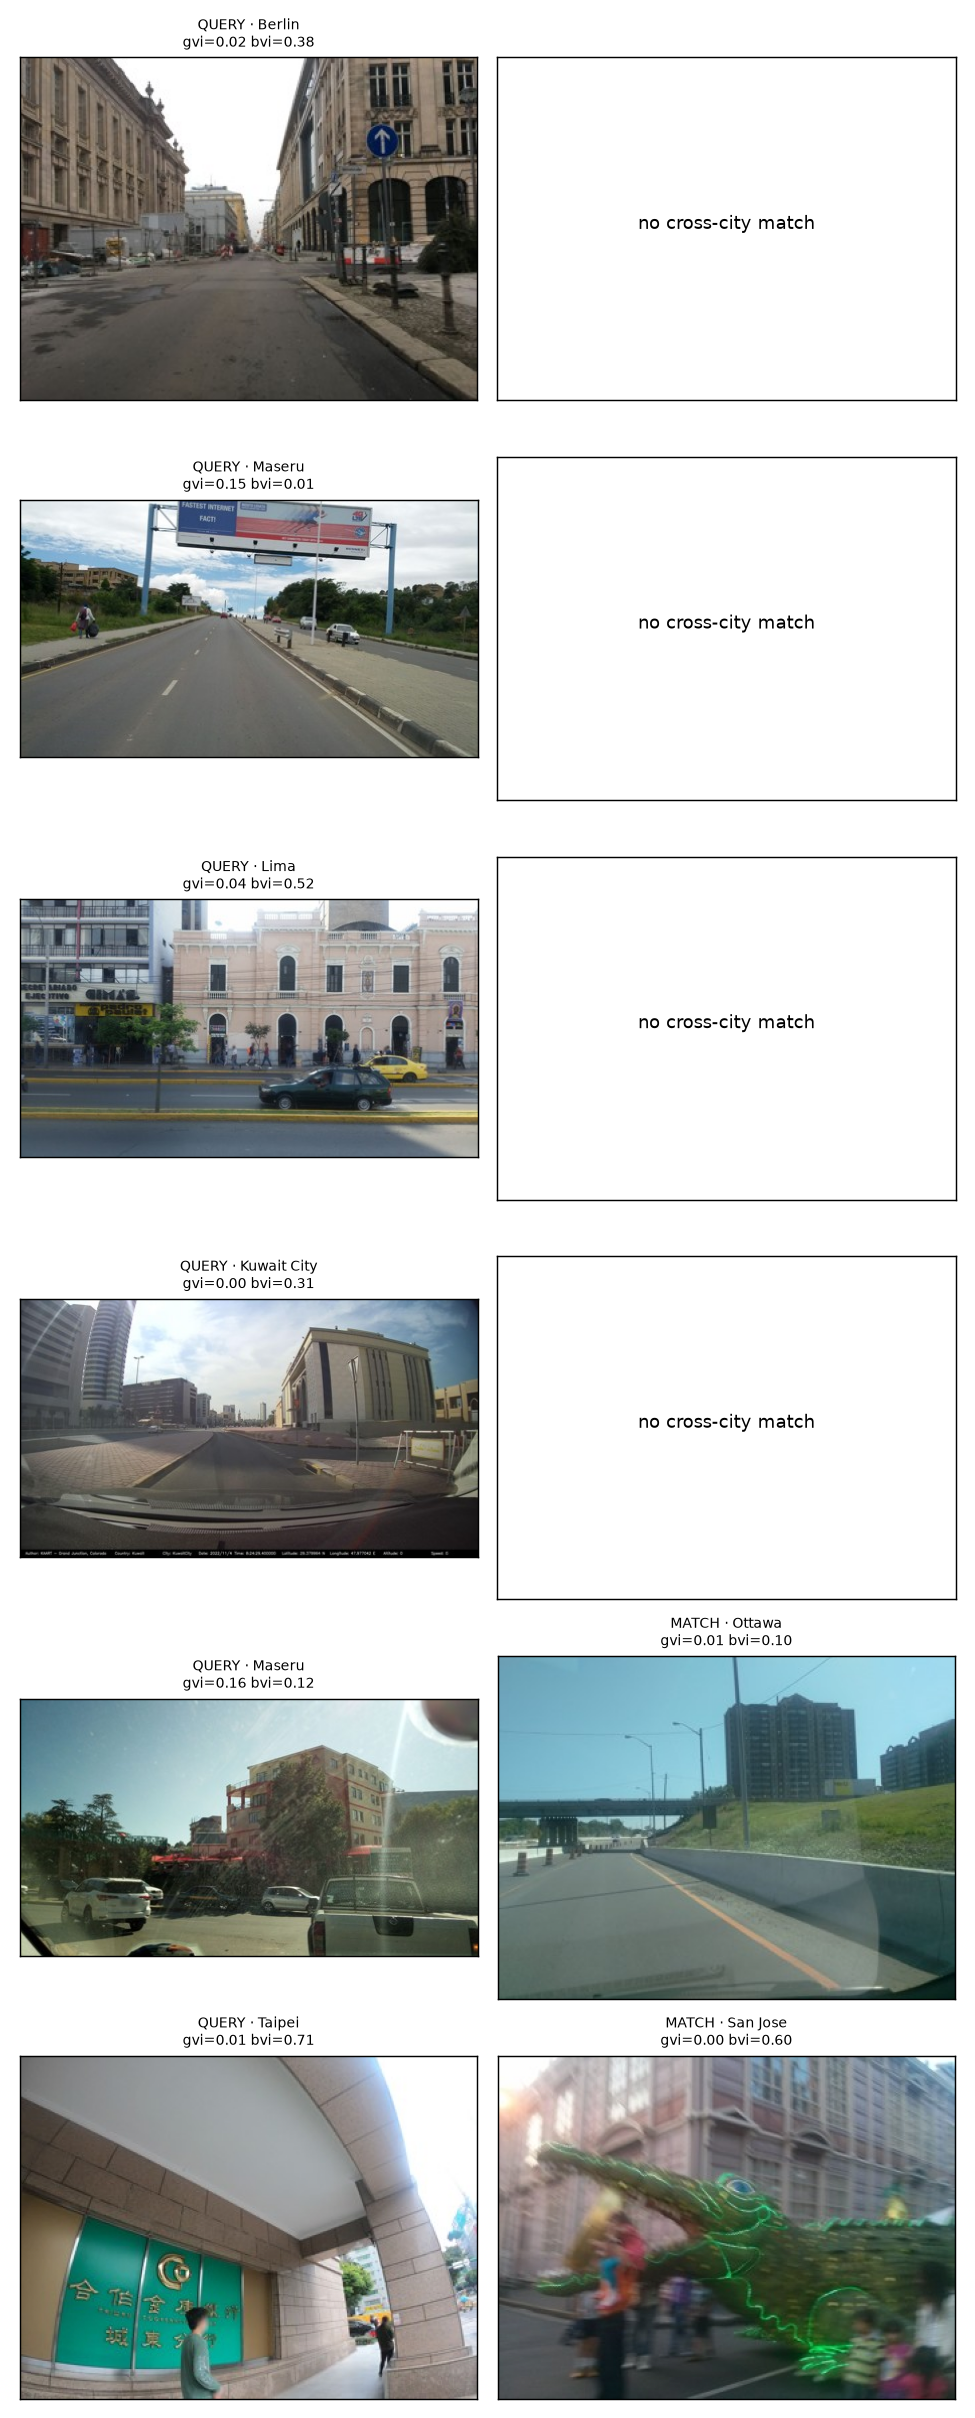

In [12]:
display(Image("outputs/stage7_map.png"))
display(Image("outputs/stage7_pairs.png"))

## Stage 8 — UMAP

Coloured by city, then the same projection recoloured by greenery.

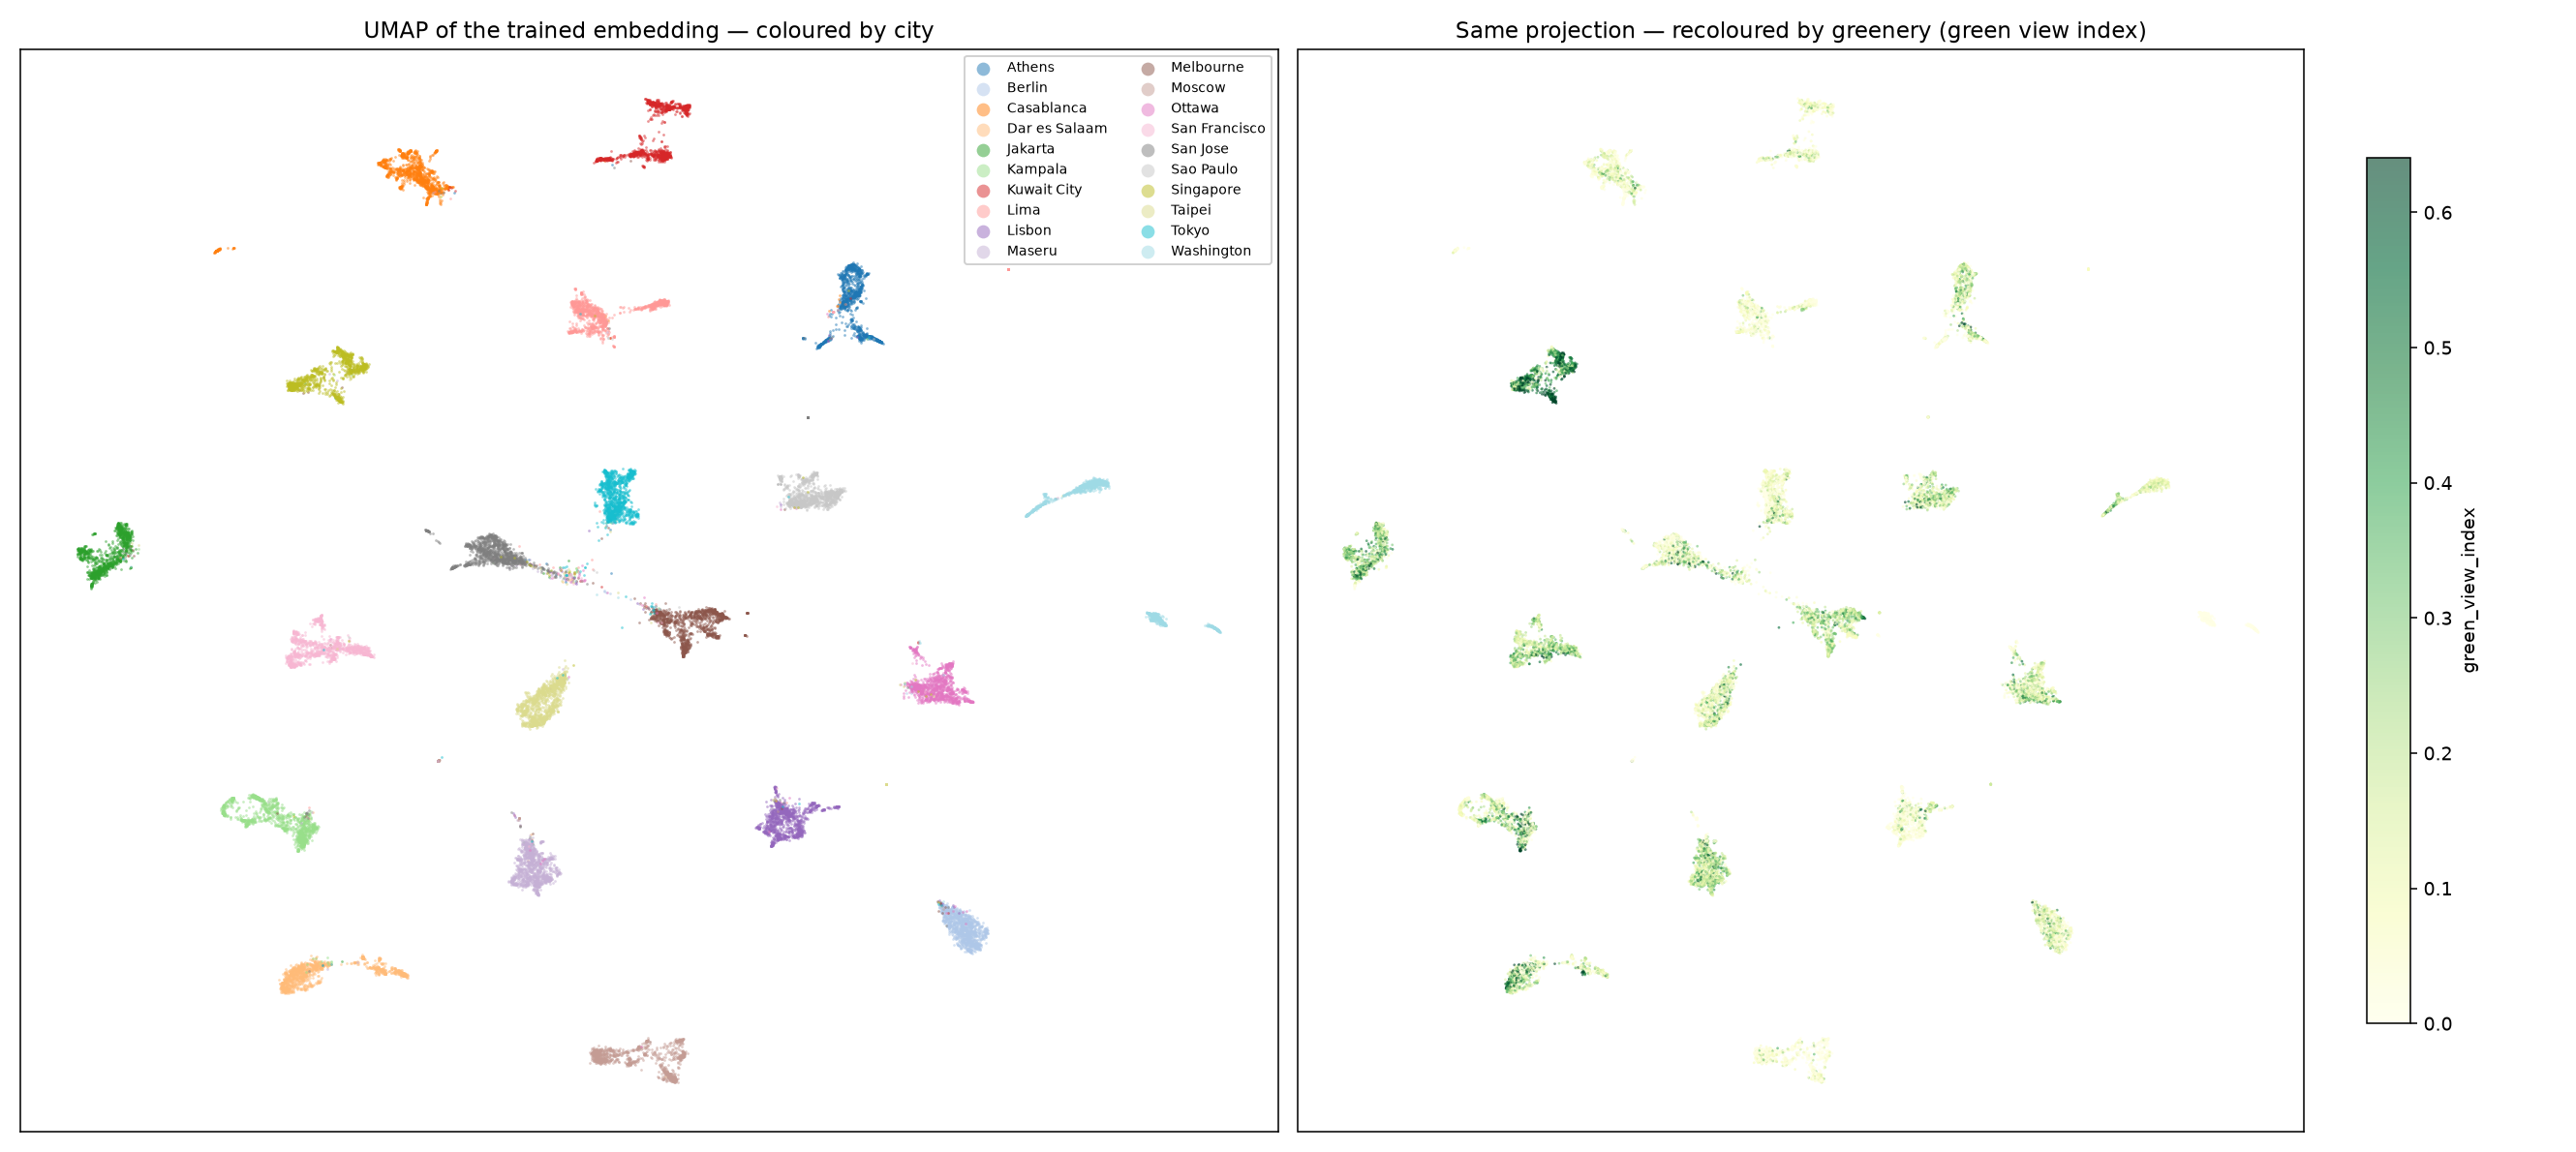

In [13]:
display(Image("outputs/stage8_umap.png"))

### What the UMAP shows

The left panel is 20 tight, disjoint islands with almost no overlap — a
near-perfect city partition, exactly what a 90.89% city classifier should look
like.

The right panel is the problem. Greenery is roughly **uniform within each
island** and there is no greenery gradient *across* the space. Singapore's
cluster is uniformly high-greenery and the rest are uniformly pale; greenery
varies between clusters only because cities happen to differ in greenery, not
because the embedding encodes it.

**The embedding is close to a city one-hot in disguise.** It has essentially no
within-manifold structure corresponding to physical attributes. That is a
complete explanation of the Stage 7 result: once the query's own city is
excluded, the nearest other-city neighbours are just whichever island sits
closest in an arbitrary arrangement, and they carry no attribute information.

A good doppelgänger embedding would look the opposite — cities interleaved, with
a smooth greenery gradient across the whole projection.

## Stage 9 — Grad-CAM: what is the model actually reading?

This section stays in the notebook whatever it shows.

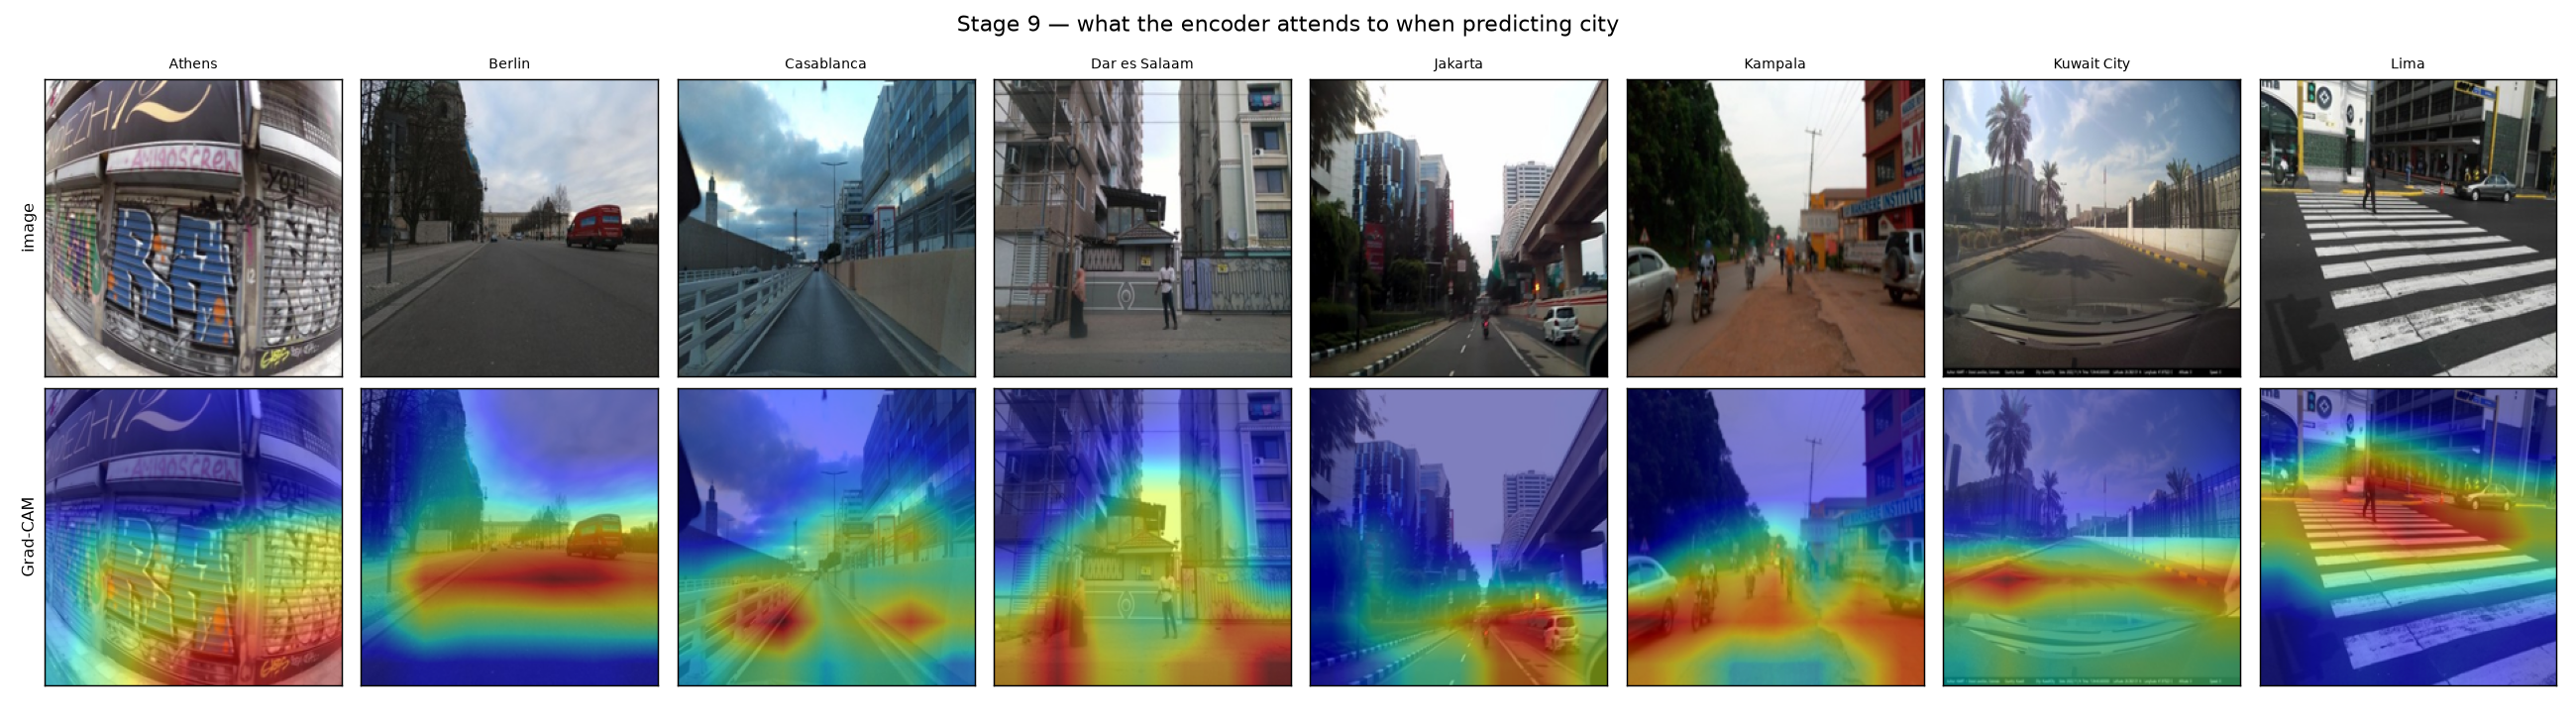

In [14]:
display(Image("outputs/stage9_gradcam.png"))

### The news is bad, as suspected

The heatmaps concentrate on:

- **road surface and lane markings** — Berlin, Casablanca, Kampala, Jakarta all
  light up strongly across the tarmac in the lower half of the frame;
- **crosswalk stripes** — Lima is the clearest case, the zebra markings are
  almost the entire activation;
- **bottom-of-frame camera furniture** — Kuwait City lights up on the strip
  where the dashcam's own text overlay and the vehicle bonnet sit.

Very little activation falls on buildings, vegetation or skyline — the things
that actually make a streetscape look the way it does.

This is precisely the shortcut this stage was written to look for. It also
reconciles the two headline numbers: road markings, kerb geometry, tarmac
colour and dashcam furniture are *superb* city identifiers, because they are
standardised nationally and the capture vehicle is often literally the same
car. They are near-useless for judging whether two streets look alike. A model
optimised for city discrimination is being actively rewarded for discarding the
shared visual structure that cross-city retrieval needs.

**The pretext task, not the training, is what failed.** City classification asks
the encoder to find what separates cities; retrieval needs what they share.
The honest conclusion is that these objectives are opposed, and the 90.89%
accuracy is evidence of the shortcut rather than evidence against it.

A follow-up would change the objective, not the architecture: a contrastive or
attribute-supervised objective, augmentations that destroy the shortcut
(aggressive bottom-of-frame cropping, colour jitter on tarmac), or masking the
road surface entirely.